# Predição de Sobrevivente: Spaceship Titanic

Este notebook concentra a parte de modelagem do projeto. A análise exploratória completa fica em `notebooks/eda.ipynb`; aqui usamos as conclusões dela para preparar os dados, treinar modelos e comparar os experimentos.

A nomenclatura dos experimentos será:
- **Caminho A**: Árvore de Decisão.
- **Caminho B**: Floresta Aleatória.

Cada experimento salva os mesmos tipos de artefatos: modelo treinado em `models/`, histórico e métricas em `reports/`, e dados/figura da curva ROC em `reports/figures/`.


## Setup do ambiente

Nesta etapa carregamos as bibliotecas, localizamos a raiz do projeto por meio de `src.roots` e criamos os diretórios de artefatos. Usar um módulo central para caminhos evita misturar diretórios do projeto com a nomenclatura dos experimentos Caminho A, Caminho B e próximos caminhos.


In [8]:
# Bibliotecas padrão
from datetime import datetime
from pathlib import Path
import sys
from time import perf_counter

# Manipulação de dados e visualização
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Persistência dos modelos treinados
from joblib import dump

# Pré-processamento, pipelines e modelos
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Estilo consistente para tabelas e gráficos do notebook.
sns.set_theme(style="whitegrid")

# Permite executar o notebook a partir da raiz do projeto ou da pasta notebooks/.
PROJECT_ROOT_HINT = Path.cwd()
if not (PROJECT_ROOT_HINT / "src").exists():
    PROJECT_ROOT_HINT = PROJECT_ROOT_HINT.parent

if str(PROJECT_ROOT_HINT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT_HINT))

from src.roots import (  # noqa: E402
    FIGURES_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    TEST_DATA_PATH,
    TRAIN_DATA_PATH,
    create_required_directories,
)

create_required_directories()

print(f"Treino: {TRAIN_DATA_PATH}")
print(f"Teste: {TEST_DATA_PATH}")
print(f"Modelos serão salvos em: {MODELS_DIR}")
print(f"Relatórios serão salvos em: {REPORTS_DIR}")


Treino: /home/gabrafo/Projetos/MineracaoDeDados/data/train.csv
Teste: /home/gabrafo/Projetos/MineracaoDeDados/data/test.csv
Modelos serão salvos em: /home/gabrafo/Projetos/MineracaoDeDados/models
Relatórios serão salvos em: /home/gabrafo/Projetos/MineracaoDeDados/reports


A próxima célula carrega os arquivos de treino e teste. O conjunto de treino contém a variável alvo `Transported`; o conjunto de teste não possui rótulos e fica disponível para inferências futuras com os modelos salvos.


In [9]:
# Carrega os dados brutos exatamente como foram fornecidos na competição.
train = pd.read_csv(TRAIN_DATA_PATH)
test = pd.read_csv(TEST_DATA_PATH)

target = "Transported"

print("Dimensões dos dados carregados")
display(
    pd.DataFrame(
        {
            "dataset": ["train", "test"],
            "linhas": [train.shape[0], test.shape[0]],
            "colunas": [train.shape[1], test.shape[1]],
        }
    )
)

print("Primeiras linhas do conjunto de treino")
display(train.head())


Dimensões dos dados carregados


,dataset,linhas,colunas
0,train,8693,14
1,test,4277,13


Primeiras linhas do conjunto de treino


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Pré-processamento

O pré-processamento transforma os dados brutos em uma matriz numérica adequada para os modelos. Essa etapa é importante porque a base mistura identificadores compostos, atributos categóricos, valores ausentes, variáveis booleanas e gastos monetários.

Vamos criar uma única pipeline de pré-processamento e reutilizá-la dentro das pipelines de cada experimento. Assim, Caminho A e Caminho B recebem exatamente as mesmas entradas transformadas, e a comparação entre os modelos fica mais justa.


A próxima célula separa `X` e `y`. Mantemos `X` ainda no formato bruto porque a engenharia de atributos fará parte da pipeline do scikit-learn. Isso garante que as transformações sejam ajustadas apenas nos folds de treino durante a validação cruzada, reduzindo risco de vazamento de dados.


In [10]:
# X preserva as colunas originais; a pipeline será responsável por derivar e descartar colunas.
X = train.drop(columns=[target])
y = train[target].astype(int)

print("Distribuição da variável alvo")
display(
    y.value_counts(normalize=True)
    .rename_axis("Transported")
    .reset_index(name="proporcao")
    .assign(proporcao=lambda df: df["proporcao"].round(4))
)


Distribuição da variável alvo


,Transported,proporcao
0,1,0.5036
1,0,0.4964


### Engenharia de atributos base

A EDA indicou que algumas colunas precisam ser abertas antes da modelagem:
- `PassengerId` contém o grupo de viagem e o número do passageiro dentro do grupo.
- `Cabin` contém convés, número e lado da cabine.
- `Name` permite extrair o sobrenome, útil para imputar `HomePlanet`.
- As cinco colunas de gastos continuam no modelo e também geram o agregado `TotalSpend`.

A próxima célula cria um transformador do scikit-learn para aplicar essas regras do mesmo modo em treino, validação, teste e inferências futuras.


In [11]:
# Colunas de gastos usadas para criar TotalSpend no pré-processamento de modelagem.
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]


class SpaceshipFeatureBuilder(BaseEstimator, TransformerMixin):
    """Cria atributos derivados a partir das colunas compostas do Spaceship Titanic."""

    def __init__(self, spend_columns=None):
        self.spend_columns = spend_columns

    def fit(self, X, y=None):
        # Guardamos uma cópia imutável da configuração para uso no transform.
        self.spend_columns_ = list(self.spend_columns or [])
        return self

    def _split_column(self, series, separator, expected_parts):
        # str.split preserva np.nan e evita o pd.NA do dtype string, que causa erro no SimpleImputer.
        parts = series.str.split(separator, expand=True)
        for col_idx in range(expected_parts):
            if col_idx not in parts.columns:
                parts[col_idx] = np.nan
        return parts

    def transform(self, X):
        out = X.copy()

        # PassengerId tem formato gggg_pp: grupo de viagem e número no grupo.
        if "PassengerId" in out.columns:
            passenger_parts = self._split_column(out["PassengerId"], "_", expected_parts=2)
            out["PassengerGroup"] = passenger_parts[0]
            out["PassengerNum"] = pd.to_numeric(passenger_parts[1], errors="coerce")

        # Cabin tem formato deck/num/side: convés, número e lado da cabine.
        if "Cabin" in out.columns:
            cabin_parts = self._split_column(out["Cabin"], "/", expected_parts=3)
            out["CabinDeck"] = cabin_parts[0]
            out["CabinNum"] = pd.to_numeric(cabin_parts[1], errors="coerce")
            out["CabinSide"] = cabin_parts[2]

        # O sobrenome ajuda a recuperar HomePlanet quando membros da família compartilham origem.
        if "Name" in out.columns:
            out["FamilyName"] = out["Name"].str.strip().str.rsplit(" ", n=1).str[-1]

        # TotalSpend complementa os gastos individuais; não substitui as cinco colunas originais.
        available_spend_cols = [col for col in self.spend_columns_ if col in out.columns]
        if available_spend_cols:
            out["TotalSpend"] = out[available_spend_cols].sum(axis=1, min_count=1)

        # Removemos identificadores brutos e componentes menos úteis; mantemos os gastos individuais.
        cols_to_drop = [
            "PassengerId",
            "Cabin",
            "Name",
            "PassengerNum",
            "CabinNum",
        ]
        out = out.drop(columns=cols_to_drop, errors="ignore")

        # Normaliza tipos categóricos para object + np.nan; isso evita o erro "boolean value of NA is ambiguous".
        categorical_like = out.select_dtypes(include=["object", "string", "category", "boolean"]).columns
        for col in categorical_like:
            out[col] = out[col].astype(object).where(out[col].notna(), np.nan)

        return out


feature_builder = SpaceshipFeatureBuilder(spend_columns=spend_cols)

feature_preview = feature_builder.fit_transform(X).head()
print("Prévia dos atributos após a engenharia base")
display(feature_preview)


Prévia dos atributos após a engenharia base


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,PassengerGroup,CabinDeck,CabinSide,FamilyName,TotalSpend
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,B,P,Ofracculy,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,F,S,Vines,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,A,S,Susent,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,A,S,Susent,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,F,S,Santantines,1091.0


### Imputação de HomePlanet por regras

`HomePlanet` tem relação com o grupo de viagem e com o sobrenome. Por isso, a primeira parte da imputação usa regras determinísticas aprendidas apenas no treino:
- se houver pessoas do mesmo `PassengerGroup` com `HomePlanet` conhecido, usamos a moda do grupo;
- se ainda faltar valor, usamos a moda do `FamilyName`.

Essa etapa é interpretável e tende a preservar relações familiares e de viagem observadas na EDA.


In [12]:
class HomePlanetRuleImputer(BaseEstimator, TransformerMixin):
    """Preenche HomePlanet pela moda do grupo de viagem e depois pela moda da família."""

    def __init__(self, group_col="PassengerGroup", family_col="FamilyName", target_col="HomePlanet"):
        self.group_col = group_col
        self.family_col = family_col
        self.target_col = target_col

    @staticmethod
    def _mode_or_nan(series):
        # Em caso de empate, a ordenação deixa o resultado determinístico.
        values = series.dropna()
        if values.empty:
            return np.nan
        mode_values = values.mode()
        if mode_values.empty:
            return np.nan
        return mode_values.sort_values().iloc[0]

    def fit(self, X, y=None):
        df = X.copy()

        if self.group_col in df.columns and self.target_col in df.columns:
            self.group_mode_ = df.groupby(self.group_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.group_mode_ = pd.Series(dtype=object)

        if self.family_col in df.columns and self.target_col in df.columns:
            self.family_mode_ = df.groupby(self.family_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.family_mode_ = pd.Series(dtype=object)

        return self

    def transform(self, X):
        df = X.copy()
        if self.target_col not in df.columns:
            return df

        homeplanet = df[self.target_col].copy()

        # Primeiro fallback: origem mais frequente dentro do mesmo grupo de viagem.
        if self.group_col in df.columns:
            group_fill = df[self.group_col].map(self.group_mode_)
            homeplanet = homeplanet.fillna(group_fill)

        # Segundo fallback: origem mais frequente para o mesmo sobrenome.
        if self.family_col in df.columns:
            family_fill = df[self.family_col].map(self.family_mode_)
            homeplanet = homeplanet.fillna(family_fill)

        df[self.target_col] = homeplanet.astype(object).where(homeplanet.notna(), np.nan)
        return df


### Imputação de HomePlanet com fallback KNN

Depois das regras por grupo e família, alguns registros podem continuar sem `HomePlanet`. Para esses casos, usamos KNN como fallback: `HomePlanet` é codificado numericamente, combinado com atributos numéricos disponíveis e imputado com base em vizinhos parecidos.

Como o KNN produz valores contínuos, arredondamos o código imputado para a categoria válida mais próxima antes de voltar ao rótulo original.


In [13]:
class HomePlanetKNNFallbackImputer(BaseEstimator, TransformerMixin):
    """Usa KNN para preencher HomePlanet remanescente após imputações por regra."""

    def __init__(self, target_col="HomePlanet", knn_neighbors=5, knn_features=None):
        self.target_col = target_col
        self.knn_neighbors = knn_neighbors
        self.knn_features = knn_features

    def _resolve_knn_features(self, df):
        if self.knn_features is not None:
            return [col for col in self.knn_features if col in df.columns]

        # O fallback usa apenas colunas numéricas para manter a matriz do KNN simples e estável.
        return [
            col
            for col in df.columns
            if col != self.target_col and pd.api.types.is_numeric_dtype(df[col])
        ]

    def _build_knn_frame(self, df, homeplanet_series):
        homeplanet_code = homeplanet_series.map(self.homeplanet_mapping_)
        feature_frame = df[self.knn_features_].copy() if self.knn_features_ else pd.DataFrame(index=df.index)
        return pd.concat([homeplanet_code.rename("homeplanet_code"), feature_frame], axis=1)

    def fit(self, X, y=None):
        df = X.copy()
        if self.target_col not in df.columns:
            self.homeplanet_categories_ = []
            self.homeplanet_mapping_ = {}
            self.knn_features_ = []
            self.knn_imputer_ = None
            return self

        self.homeplanet_categories_ = sorted(df[self.target_col].dropna().unique().tolist())
        self.homeplanet_mapping_ = {
            value: idx for idx, value in enumerate(self.homeplanet_categories_)
        }
        self.knn_features_ = self._resolve_knn_features(df)

        self.knn_imputer_ = KNNImputer(n_neighbors=self.knn_neighbors)
        knn_frame = self._build_knn_frame(df, df[self.target_col])
        self.knn_imputer_.fit(knn_frame)
        return self

    def transform(self, X):
        df = X.copy()
        if (
            self.target_col not in df.columns
            or not self.homeplanet_categories_
            or self.knn_imputer_ is None
        ):
            return df

        missing = df[self.target_col].isna()
        if not missing.any():
            df[self.target_col] = df[self.target_col].astype(object).where(df[self.target_col].notna(), np.nan)
            return df

        knn_frame = self._build_knn_frame(df, df[self.target_col])
        imputed = self.knn_imputer_.transform(knn_frame)
        imputed_codes = imputed[:, 0]

        max_code = len(self.homeplanet_categories_) - 1
        imputed_codes = np.clip(np.rint(imputed_codes), 0, max_code).astype(int)
        imputed_labels = pd.Series(
            [self.homeplanet_categories_[code] for code in imputed_codes],
            index=df.index,
        )

        df[self.target_col] = df[self.target_col].fillna(imputed_labels)
        df[self.target_col] = df[self.target_col].astype(object).where(df[self.target_col].notna(), np.nan)
        return df


### Pipeline de pré-processamento

A próxima célula monta a pipeline compartilhada. Ela aplica a engenharia de atributos, imputa `HomePlanet`, transforma variáveis numéricas, binárias e categóricas, e entrega uma matriz pronta para o classificador.

As escolhas principais são:
- `KNNImputer` e `StandardScaler` para numéricas (`Age`, gastos individuais e `TotalSpend`);
- `OrdinalEncoder` + `KNNImputer` para binárias (`CabinSide`, `CryoSleep`, `VIP`);
- `SimpleImputer` + `OneHotEncoder` para categóricas de múltiplas classes.


In [14]:
# Colunas esperadas depois de SpaceshipFeatureBuilder.
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "TotalSpend"]
binary_cols = ["CabinSide", "CryoSleep", "VIP"]
categorical_ohe = ["CabinDeck", "Destination", "HomePlanet", "PassengerGroup", "FamilyName"]


def round_binary(values):
    """Arredonda saídas do KNN para os códigos binários 0/1."""
    return np.clip(np.rint(values), 0, 1).astype(int)


numeric_pipeline = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OrdinalEncoder(
                categories=[["P", "S"], [False, True], [False, True]],
                handle_unknown="use_encoded_value",
                unknown_value=np.nan,
            ),
        ),
        ("imputer", KNNImputer(n_neighbors=5)),
        ("rounder", FunctionTransformer(round_binary, feature_names_out="one-to-one")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_ohe),
    ],
    remainder="drop",
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        ("homeplanet_rules", HomePlanetRuleImputer()),
        (
            "homeplanet_knn",
            HomePlanetKNNFallbackImputer(
                knn_neighbors=5,
                knn_features=numeric_cols,
            ),
        ),
        ("columns", column_preprocessor),
    ]
)

print("Pipeline de pré-processamento compartilhada")
preprocessing_pipeline


Pipeline de pré-processamento compartilhada


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'
,target_col,'HomePlanet'
,knn_neighbors,5
,knn_features,"['Age', 'RoomService', ...]"


Ao final do pré-processamento, temos uma etapa única e reutilizável que:
- cria atributos derivados de identificadores compostos;
- mantém os gastos individuais e adiciona `TotalSpend` como agregado;
- preenche `HomePlanet` em duas camadas;
- codifica variáveis categóricas e binárias;
- trata valores ausentes antes do treinamento.

Essa mesma pipeline será instanciada dentro das pipelines de Caminho A e Caminho B.


## Configuração comum de avaliação e artefatos

Antes dos modelos, definimos apenas utilitários pequenos e reutilizáveis: criação da pipeline completa, cálculo de métricas e salvamento padronizado dos artefatos. A execução de cada experimento ficará em uma célula própria, para deixar o fluxo de treino e avaliação mais direto.

Os arquivos salvos seguem o padrão `history_path_*_timestamp.csv`, `metrics_path_*_timestamp.csv`, `roc_path_*_timestamp.csv` e `model_path_*_timestamp.joblib`.


In [15]:
def make_model_pipeline(estimator):
    """Cria uma pipeline completa com uma cópia limpa do pré-processamento compartilhado."""
    return Pipeline(
        steps=[
            ("preprocess", clone(preprocessing_pipeline)),
            ("model", estimator),
        ]
    )


def classification_metrics(y_true, y_pred, y_score):
    """Calcula métricas globais para um fold ou para as predições out-of-fold."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1_class_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_class_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def build_artifact_files(experiment_id, timestamp=None):
    """Gera nomes de arquivos padronizados para os artefatos do experimento."""
    timestamp = timestamp or datetime.now().strftime("%Y%m%d_%H%M%S")
    experiment_slug = experiment_id.lower().replace(" ", "_")

    return {
        "timestamp": timestamp,
        "model": MODELS_DIR / f"model_{experiment_slug}_{timestamp}.joblib",
        "history": REPORTS_DIR / f"history_{experiment_slug}_{timestamp}.csv",
        "metrics": REPORTS_DIR / f"metrics_{experiment_slug}_{timestamp}.csv",
        "roc_csv": FIGURES_DIR / f"roc_{experiment_slug}_{timestamp}.csv",
        "roc_png": FIGURES_DIR / f"roc_{experiment_slug}_{timestamp}.png",
    }


def save_experiment_artifacts(fitted_pipeline, history_df, metrics_df, roc_df, roc_fig, artifact_files):
    """Salva modelo, histórico, métricas e curva ROC com a mesma convenção."""
    dump(fitted_pipeline, artifact_files["model"])
    history_df.to_csv(artifact_files["history"], index=False)
    metrics_df.to_csv(artifact_files["metrics"], index=False)
    roc_df.to_csv(artifact_files["roc_csv"], index=False)
    roc_fig.savefig(artifact_files["roc_png"], dpi=160, bbox_inches="tight")


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metric_cols = ["accuracy", "precision", "recall", "f1", "f1_class_0", "f1_class_1", "roc_auc"]


## Árvore de Decisão

Uma árvore de decisão aprende uma sequência de perguntas sobre os atributos. Em cada nó, o algoritmo escolhe uma divisão que separa melhor as classes; no final, cada folha representa uma regra de decisão e retorna uma classe provável.

A vantagem é a interpretação simples. A limitação é que árvores isoladas podem se ajustar demais ao treino quando crescem sem controle, por isso a validação cruzada é essencial para medir generalização.


### Treinamento

Caminho A usa `DecisionTreeClassifier`. A pipeline completa contém duas partes: primeiro o pré-processamento compartilhado, depois o classificador. Nesta primeira versão mantemos os hiperparâmetros padrão do modelo e fixamos `random_state=42` para reprodutibilidade.


In [16]:
path_a_estimator = DecisionTreeClassifier(random_state=42)
path_a_pipeline = make_model_pipeline(path_a_estimator)

print("Pipeline do Caminho A")
path_a_pipeline


Pipeline do Caminho A


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,group_col,'PassengerGroup'
,family_col,'FamilyName'


### Avaliação

A avaliação do Caminho A usa validação cruzada estratificada com 10 folds. Em cada fold medimos acurácia, precisão, recall, F1, F1 por classe e ROC AUC. A curva ROC é construída a partir das predições out-of-fold, ou seja, cada ponto previsto vem de um modelo que não treinou naquele registro.

Ao final, treinamos novamente a pipeline em todo o conjunto de treino e salvamos modelo, histórico, métricas e ROC com o padrão de artefatos do projeto.


Artefatos salvos para Caminho A - Árvore de Decisão
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_a_20260601_133720.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_a_20260601_133720.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_a_20260601_133720.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_a_20260601_133720.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_a_20260601_133720.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_a,Caminho A - Árvore de Decisão,accuracy,0.7787,0.0151,0.7787
1,path_a,Caminho A - Árvore de Decisão,precision,0.7779,0.0145,0.7779
2,path_a,Caminho A - Árvore de Decisão,recall,0.7846,0.0203,0.7846
3,path_a,Caminho A - Árvore de Decisão,f1,0.7811,0.0158,0.7812
4,path_a,Caminho A - Árvore de Decisão,f1_class_0,0.7761,0.0148,0.7761
5,path_a,Caminho A - Árvore de Decisão,f1_class_1,0.7811,0.0158,0.7812
6,path_a,Caminho A - Árvore de Decisão,roc_auc,0.7786,0.0151,0.7786


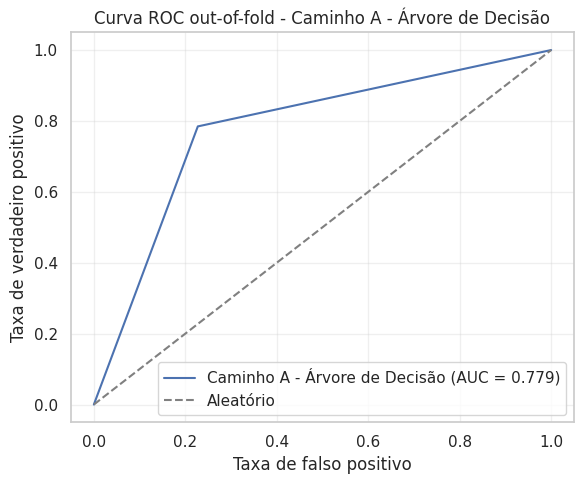

In [17]:
# Avaliação e salvamento do Caminho A - Árvore de Decisão
experiment_id = "path_a"
experiment_label = "Caminho A - Árvore de Decisão"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_a_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_a_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_a_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_a_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_a_oof_pred.iloc[valid_idx] = fold_pred
    path_a_oof_score.iloc[valid_idx] = fold_score

    path_a_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_a_history = pd.DataFrame(path_a_history_rows)
path_a_oof_metrics = classification_metrics(
    y_cv,
    path_a_oof_pred.astype(int),
    path_a_oof_score.astype(float),
)

path_a_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_a_history[metric].mean(),
            "cv_std": path_a_history[metric].std(ddof=0),
            "out_of_fold": path_a_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_a_oof_score.astype(float))
path_a_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_a_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_a_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_a_final_pipeline = clone(path_a_pipeline)
path_a_final_pipeline.fit(X_cv, y_cv)

path_a_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_a_final_pipeline,
    history_df=path_a_history,
    metrics_df=path_a_metrics,
    roc_df=path_a_roc,
    roc_fig=path_a_fig,
    artifact_files=path_a_artifacts,
)

path_a_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_a_final_pipeline,
    "history": path_a_history,
    "metrics": path_a_metrics,
    "roc": path_a_roc,
    "artifact_files": path_a_artifacts,
    "oof_pred": path_a_oof_pred.astype(int),
    "oof_score": path_a_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_a_artifacts[key]}")

display(path_a_metrics.round(4))
plt.show()


## Floresta Aleatória

Uma floresta aleatória combina várias árvores de decisão treinadas com amostras e subconjuntos de atributos diferentes. Cada árvore vota em uma classe, e o conjunto tende a ser mais estável do que uma árvore única.

A vantagem principal é reduzir variância e melhorar generalização. O custo é menor interpretabilidade e mais tempo de treinamento.


### Treinamento

Caminho B usa `RandomForestClassifier` com `n_estimators=200`, ou seja, 200 árvores no conjunto. Mantemos `random_state=42` para reprodutibilidade e `n_jobs=-1` para permitir paralelização interna do modelo.

A pipeline de entrada é a mesma do Caminho A: pré-processamento compartilhado seguido do classificador.


In [18]:
path_b_estimator = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
path_b_pipeline = make_model_pipeline(path_b_estimator)

print("Pipeline do Caminho B")
path_b_pipeline


Pipeline do Caminho B


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,group_col,'PassengerGroup'
,family_col,'FamilyName'


### Avaliação

O Caminho B é avaliado com o mesmo procedimento do Caminho A. Isso mantém a comparação justa: mesmos folds, mesmas métricas, mesma forma de gerar a curva ROC out-of-fold e mesma rotina de salvamento de artefatos.


Artefatos salvos para Caminho B - Floresta Aleatória
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_b_20260601_133810.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_b_20260601_133810.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_b_20260601_133810.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_b_20260601_133810.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_b_20260601_133810.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_b,Caminho B - Floresta Aleatória,accuracy,0.7959,0.0164,0.7959
1,path_b,Caminho B - Floresta Aleatória,precision,0.8180,0.0169,0.8180
2,path_b,Caminho B - Floresta Aleatória,recall,0.7650,0.0201,0.7650
3,path_b,Caminho B - Floresta Aleatória,f1,0.7905,0.0175,0.7906
4,path_b,Caminho B - Floresta Aleatória,f1_class_0,0.8010,0.0156,0.8010
5,path_b,Caminho B - Floresta Aleatória,f1_class_1,0.7905,0.0175,0.7906
6,path_b,Caminho B - Floresta Aleatória,roc_auc,0.8738,0.0147,0.8738


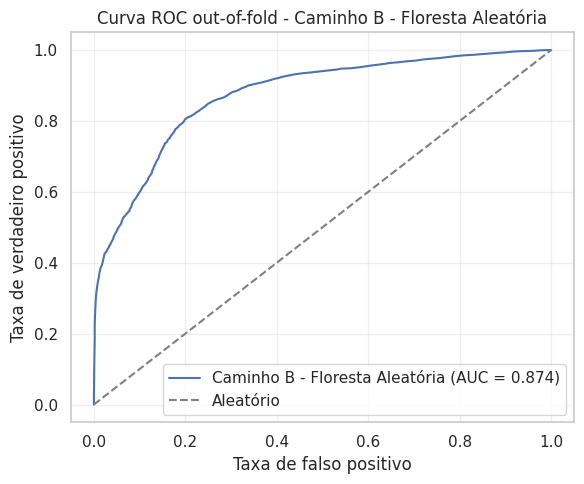

In [19]:
# Avaliação e salvamento do Caminho B - Floresta Aleatória
experiment_id = "path_b"
experiment_label = "Caminho B - Floresta Aleatória"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_b_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_b_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_b_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_b_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_b_oof_pred.iloc[valid_idx] = fold_pred
    path_b_oof_score.iloc[valid_idx] = fold_score

    path_b_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_b_history = pd.DataFrame(path_b_history_rows)
path_b_oof_metrics = classification_metrics(
    y_cv,
    path_b_oof_pred.astype(int),
    path_b_oof_score.astype(float),
)

path_b_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_b_history[metric].mean(),
            "cv_std": path_b_history[metric].std(ddof=0),
            "out_of_fold": path_b_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_b_oof_score.astype(float))
path_b_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_b_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_b_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_b_final_pipeline = clone(path_b_pipeline)
path_b_final_pipeline.fit(X_cv, y_cv)

path_b_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_b_final_pipeline,
    history_df=path_b_history,
    metrics_df=path_b_metrics,
    roc_df=path_b_roc,
    roc_fig=path_b_fig,
    artifact_files=path_b_artifacts,
)

path_b_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_b_final_pipeline,
    "history": path_b_history,
    "metrics": path_b_metrics,
    "roc": path_b_roc,
    "artifact_files": path_b_artifacts,
    "oof_pred": path_b_oof_pred.astype(int),
    "oof_score": path_b_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_b_artifacts[key]}")

display(path_b_metrics.round(4))
plt.show()


## Benchmarking

Nesta avaliação geral, reunimos as métricas out-of-fold dos dois experimentos e criamos um ranking. O F1 é usado como critério principal porque combina precisão e recall; em caso de empate, olhamos ROC AUC e acurácia.


In [20]:
def benchmark_row(result):
    """Transforma a tabela de métricas de um experimento em uma linha para ranking."""
    metrics = result["metrics"].set_index("metric")["out_of_fold"].to_dict()
    return {
        "experiment_id": result["experiment_id"],
        "experiment_label": result["experiment_label"],
        **metrics,
        "model_artifact": result["artifact_files"]["model"],
        "metrics_artifact": result["artifact_files"]["metrics"],
        "roc_artifact": result["artifact_files"]["roc_csv"],
    }


benchmark = pd.DataFrame([benchmark_row(path_a_results), benchmark_row(path_b_results)])
benchmark = benchmark.sort_values(
    by=["f1", "roc_auc", "accuracy"],
    ascending=False,
).reset_index(drop=True)

print("Ranking dos experimentos por F1, ROC AUC e acurácia")
display(
    benchmark[
        [
            "experiment_id",
            "experiment_label",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f1_class_0",
            "f1_class_1",
            "roc_auc",
        ]
    ].round(4)
)

print("Artefatos principais por experimento")
display(benchmark[["experiment_id", "model_artifact", "metrics_artifact", "roc_artifact"]])


Ranking dos experimentos por F1, ROC AUC e acurácia


,experiment_id,experiment_label,accuracy,precision,recall,f1,f1_class_0,f1_class_1,roc_auc
0,path_b,Caminho B - Floresta Aleatória,0.7959,0.8180,0.7650,0.7906,0.8010,0.7906,0.8738
1,path_a,Caminho A - Árvore de Decisão,0.7787,0.7779,0.7846,0.7812,0.7761,0.7812,0.7786


Artefatos principais por experimento


,experiment_id,model_artifact,metrics_artifact,roc_artifact
0,path_b,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
1,path_a,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
